### **K-MEANS CLUSTERING**

In [ ]:
#import library
import pandas as pd

#read csv file
data=pd.read_csv('https://confrecordings.ams3.digitaloceanspaces.com/Market_Segmentation.csv')

#perform EDA
print(data.head())
print(data.shape)
print(data.isnull().sum())
print(data.corr())

   Satisfaction  Loyalty
0             4    -1.33
1             6    -0.28
2             5    -0.99
3             7    -0.29
4             4     1.06
(30, 2)
Satisfaction    0
Loyalty         0
dtype: int64
              Satisfaction   Loyalty
Satisfaction      1.000000  0.366929
Loyalty           0.366929  1.000000


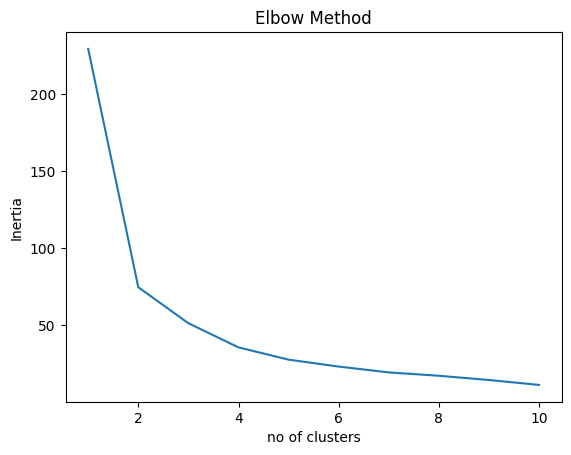

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#write your code here

#make empty list
clusters = []

#plot elbow curve for 10 clusters
for i in range(1,11):
  kmeans = KMeans(n_clusters= i, init='k-means++', random_state=0)
  kmeans.fit(data)
  clusters.append(kmeans.inertia_)
plt.plot(range(1,11),clusters)
plt.title('Elbow Method')
plt.xlabel('no of clusters')
plt.ylabel('Inertia')
plt.show()

### **Train the model with K-means**

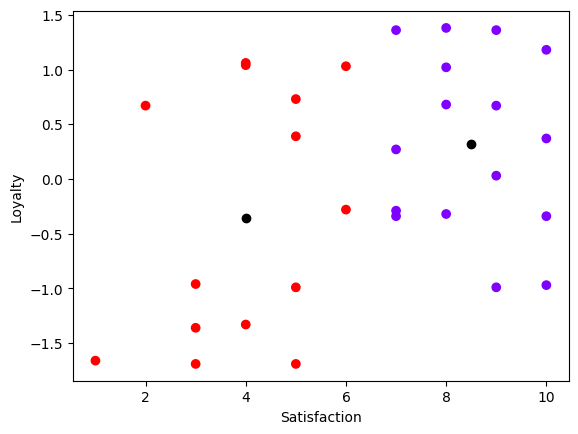

In [ ]:
#Load KMeans
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=0)
#Train model
kmeans.fit(data)

#Find centroids
centroids = kmeans.cluster_centers_
cluster_new=data.copy()

#predict
cluster_new['new_cluster_pred'] = kmeans.fit_predict(data)

#plot new clusters and centroids and show the plot
plt.scatter(cluster_new['Satisfaction'], cluster_new['Loyalty'],
            c=cluster_new['new_cluster_pred'], cmap='rainbow')
plt.scatter(centroids[:,0], centroids[:,1],color='black')
plt.xlabel('Satisfaction')
plt.ylabel('Loyalty')
plt.show()

### **HIERARCHICAL CLUSTERING**

In [ ]:
#import library

import pandas as pd
data=pd.read_csv('https://confrecordings.ams3.digitaloceanspaces.com/Wholesale%20customers%20data.csv')

#Perform EDA

print(data.head())
print(data.columns)
print(data.shape)
print(data.isnull().info())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')
(440, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    bool 
 1   Region            440 non-null    bool 
 2   Fresh             440 non-null    bool 
 3   Milk              440 non-null    bool 
 4   Grocery 

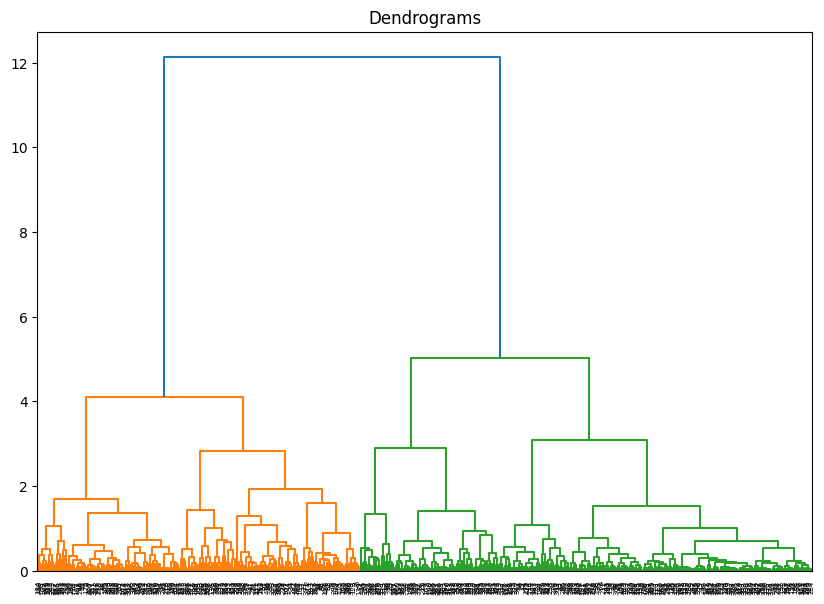

In [ ]:
#Normalize the data
from sklearn.preprocessing import normalize
data_scaled = normalize(data)
data_scaled = pd.DataFrame(data_scaled, columns=data.columns)
data_scaled.head()

#Plot the dendrogram
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))
plt.show()

AgglomerativeClustering()


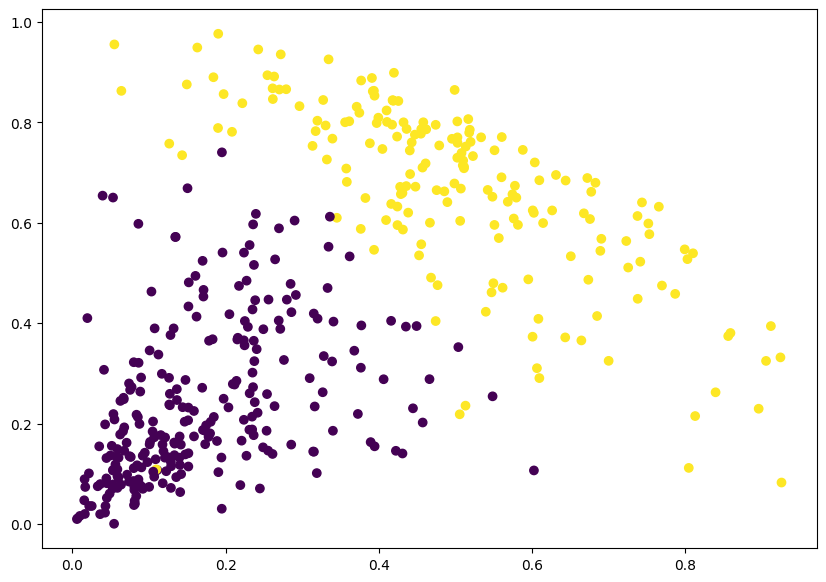

In [ ]:
#Normalize the data
from sklearn.preprocessing import normalize
data_scaled = normalize(data)
data_scaled = pd.DataFrame(data_scaled, columns=data.columns)
data_scaled.head()

#Train the model
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean',
                                  linkage='ward')
cluster.fit_predict(data_scaled)
print(cluster)

#Plot the graph & Evaluate result
plt.figure(figsize=(10, 7))
plt.scatter(data_scaled['Milk'], data_scaled['Grocery'], c=cluster.labels_)
plt.show()

### **DBSCAN Clustering**

['y', 'b', 'g', 'r']


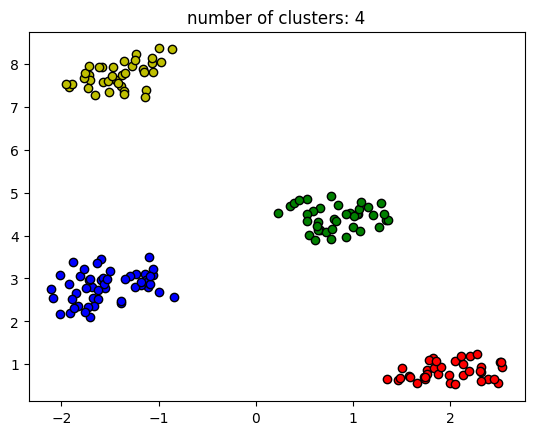

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
# Load data in X
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.50, random_state=0)
db = DBSCAN(eps=0.3, min_samples=10).fit(X)

core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Plot result

# Black removed and is used for noise instead.
unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = 'k'

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()

